In [1]:
%reload_ext autoreload
%autoreload 2
from diffusers import DDIMScheduler, DDIMInverseScheduler
from diffusers import ControlNetModel
from diffusers.utils import make_image_grid
from pipeline_controlnet import StableDiffusionControlNetPipeline
from PIL import Image
import torch

In [2]:
controlnet = ControlNetModel.from_pretrained("thibaud/controlnet-sd21-scribble-diffusers", torch_dtype=torch.float16)

An error occurred while trying to fetch thibaud/controlnet-sd21-scribble-diffusers: thibaud/controlnet-sd21-scribble-diffusers does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


In [3]:
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "stabilityai/stable-diffusion-2-1-base",
    controlnet=controlnet,
    torch_dtype=torch.float16, use_safetensors=True
).to("cuda")

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

In [4]:
sketch = Image.open("/data2/kietngt00/score-distillation-via-inversion/data/sketch/a_baby_penguin_wearing_a_blue_hat.png").convert('RGB').resize((512, 512))

In [11]:
import random
import numpy as np
import os
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
seed_everything(1505)

  0%|          | 0/50 [00:00<?, ?it/s]

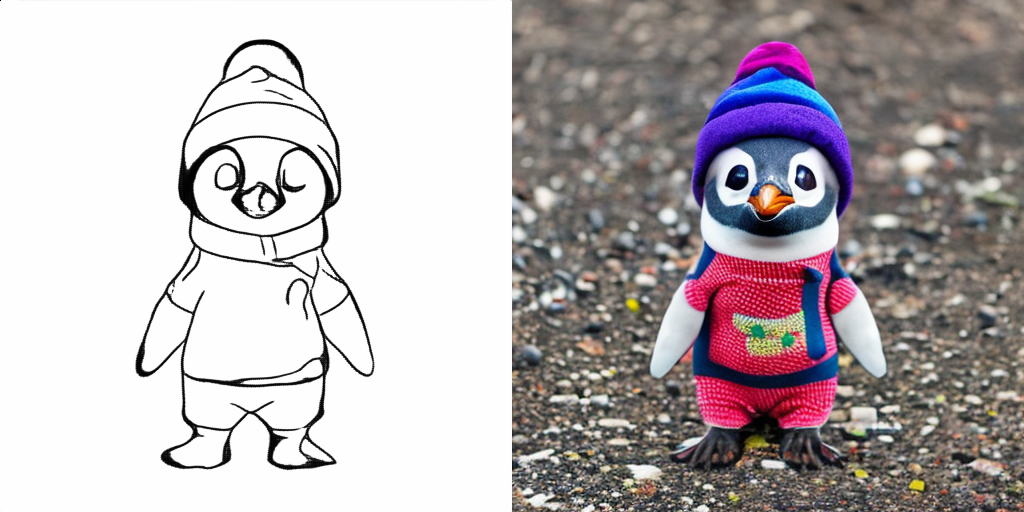

In [13]:
output = pipe(
    "a baby penguin wearing a colorful hat", image=sketch
).images[0]
make_image_grid([sketch, output], rows=1, cols=2)